In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from multipred.plotting import pointplot_morey

In [31]:
# simulate data
np.random.seed(0)
n = 10000
CW_prob = 0.55 # mean probability of CW when the presented orientation is CW
CCW_prob = 0.45 # mean probability of CW when the presented orientation is CCW
exp_diff = .05 # deviation from mean probability caused by predictions
spread = .3 # spread of the data

df = {"mechanism": [], "expected_ori": [], "presented_ori": [], "prob_cw": []}
# neutral trials
for mechanism in ["neutral", "sharpening", "bias"]:
    for expected_ori in ["CW", "CCW"]:
        for presented_ori in ["CW", "CCW"]:
            if mechanism == "neutral":
                prob_cw = CW_prob # + exp_diff
                prob_ccw = CCW_prob # - exp_diff

            elif mechanism == "sharpening":
                if expected_ori == "CW":
                    prob_cw = CW_prob + exp_diff # under this account the probability of CW should increase
                    prob_ccw = CCW_prob # under this account the probability of CW when CCW is unexpected should remain the same
                else:
                    prob_cw = CW_prob
                    prob_ccw = CCW_prob - exp_diff # only the probability of CW should decrease when expected CCW

            elif mechanism == "bias":
                if expected_ori == "CW":
                    prob_cw = CW_prob + exp_diff
                    prob_ccw = CCW_prob + exp_diff # under this account the probability of CW should always increase
                else:
                    prob_cw = CW_prob - exp_diff
                    prob_ccw = CCW_prob - exp_diff # under this account the probability of CW should always decrease

            # Generate the data
            if presented_ori == "CW":
                data = np.random.normal(loc=prob_cw, scale=spread, size=n)
            else:
                data = np.random.normal(loc=prob_ccw, scale=spread, size=n)
                
            df["mechanism"].extend([mechanism]*n)
            df["expected_ori"].extend([expected_ori]*n)
            df["presented_ori"].extend([presented_ori]*n)
            df["prob_cw"].extend(data)

df = pd.DataFrame(df)
df["correct"] = np.where(
    ((df["presented_ori"] == "CW") & (df["prob_cw"] > 0.5)) |
    ((df["presented_ori"] == "CCW") & (df["prob_cw"] < 0.5)),
    1,
    0
)
df["expected_ori"] = np.where(df["mechanism"] == "neutral", "neutral", df["expected_ori"])

df["visual_prediction"] = np.where(
    df["mechanism"] == "neutral",
    "neutral",
    np.where(
        df["presented_ori"] == df["expected_ori"],
        "EXP",
        "UEX"
    )
)

In [47]:
dat1

,expected_ori,presented_ori,prob_cw
0,CCW,CCW,0.402733
1,CCW,CW,0.546092
2,CW,CCW,0.451571
3,CW,CW,0.598843
4,neutral,CCW,0.451347
5,neutral,CW,0.546386


C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1146907772.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(
C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1146907772.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["CW", "CCW"], fontsize=18)
C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1146907772.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Neutral", "UEX", "EXP"], fontsize=18)


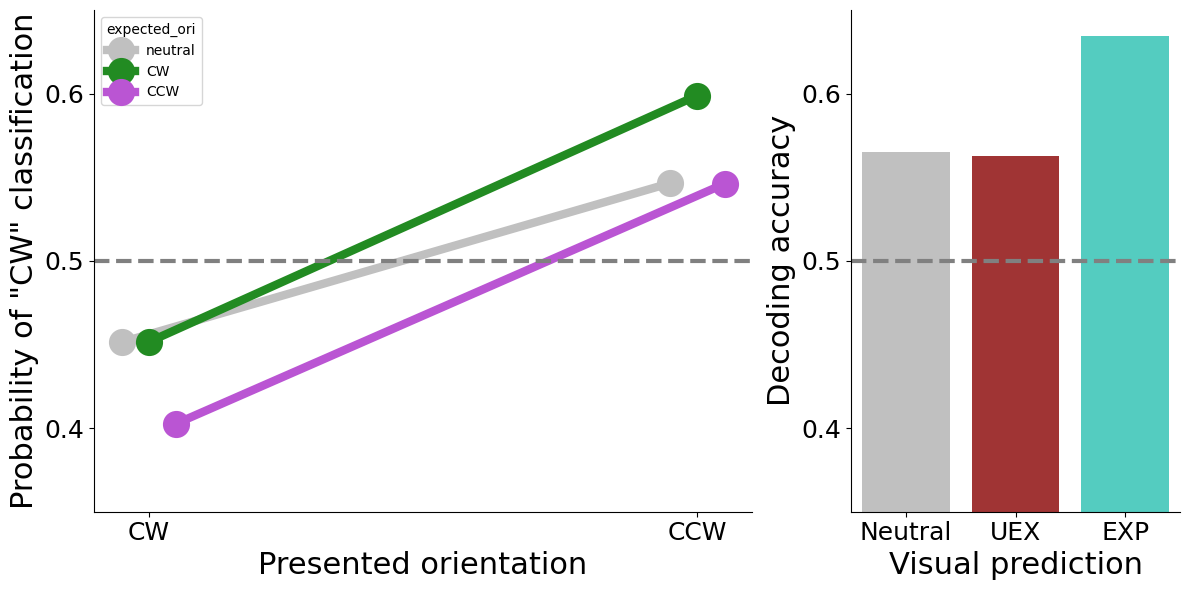

In [76]:
x="presented_ori" # Presented CW or
hue="expected_ori" # expected CW or CCW
y="prob_cw" # probability of choosing CW
savefig = True

fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=False,
    gridspec_kw={"width_ratios": [2, 1]}  # first subplot twice as wide
)

data=df[df["mechanism"]!= "bias"].copy()
dat1 = data.groupby([hue, x])[y].mean().reset_index()

palette = ["silver", "forestgreen", "mediumorchid"]
hue_order = ["neutral", "CW", "CCW"]  # explicitly specify the order of hue levels

sns.pointplot(
    data=dat1,
    x="presented_ori",
    y="prob_cw",
    hue="expected_ori",
    hue_order=hue_order,     # this ensures consistent mapping
    dodge=0.1,
    join=True,
    errorbar=None,
    palette=palette,
    linewidth=6,
    ax=ax[0]
)

ax[0].axhline(0.5, color="grey", linestyle="--", lw=3)
ax[0].set_ylim(0.35, .65)
ax[0].set_ylabel('Probability of "CW" classification', fontsize=22)
ax[0].set_xlabel("Presented orientation", fontsize=22)
ax[0].set_yticks([0.4, 0.5, 0.6])
ax[0].set_yticklabels(["0.4", "0.5", "0.6"], fontsize=18)
ax[0].set_xticklabels(["CW", "CCW"], fontsize=18)

x="visual_prediction" # Presented CW or
hue="visual_prediction" # expected CW or CCW
y="correct" # probability of choosing CW

data = df[df["mechanism"]!= "bias"].copy()
dat2 = data.groupby([x])[y].mean().reset_index()

palette = ["silver", "firebrick", "turquoise"]
cat_type = pd.CategoricalDtype(categories=["neutral", "UEX", "EXP"], ordered=True)
dat2["visual_prediction"] = dat2["visual_prediction"].astype(cat_type)

sns.barplot(
    data=dat2,
    x="visual_prediction",
    y="correct",
    hue="visual_prediction",  # optional, now redundant due to categorical type
    dodge=False,
    palette=palette,
    ax=ax[1]
)

ax[1].set_ylabel("Decoding accuracy", fontsize=22)
ax[1].set_xlabel("Visual prediction", fontsize=22)
ax[1].set_ylim(0.35, .65)
ax[1].set_yticks([0.4, 0.5, 0.6])
ax[1].set_xticklabels(["Neutral", "UEX", "EXP"], fontsize=18)
ax[1].axhline(0.5, color="grey", linestyle="--", lw=3)
ax[1].set_yticklabels(["0.4", "0.5", "0.6"], fontsize=18)

sns.despine()

ax[0].set_xlim(-0.1, 1.1)

plt.tight_layout()
if savefig:
    plt.savefig("figures/MVPA/sharpening_simulation.svg", dpi = 300)
plt.show()

C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1820125169.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(
C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1820125169.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["CW", "CCW"], fontsize=18)
C:\Users\marcs\AppData\Local\Temp\ipykernel_7732\1820125169.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Neutral", "UEX", "EXP"], fontsize=18)


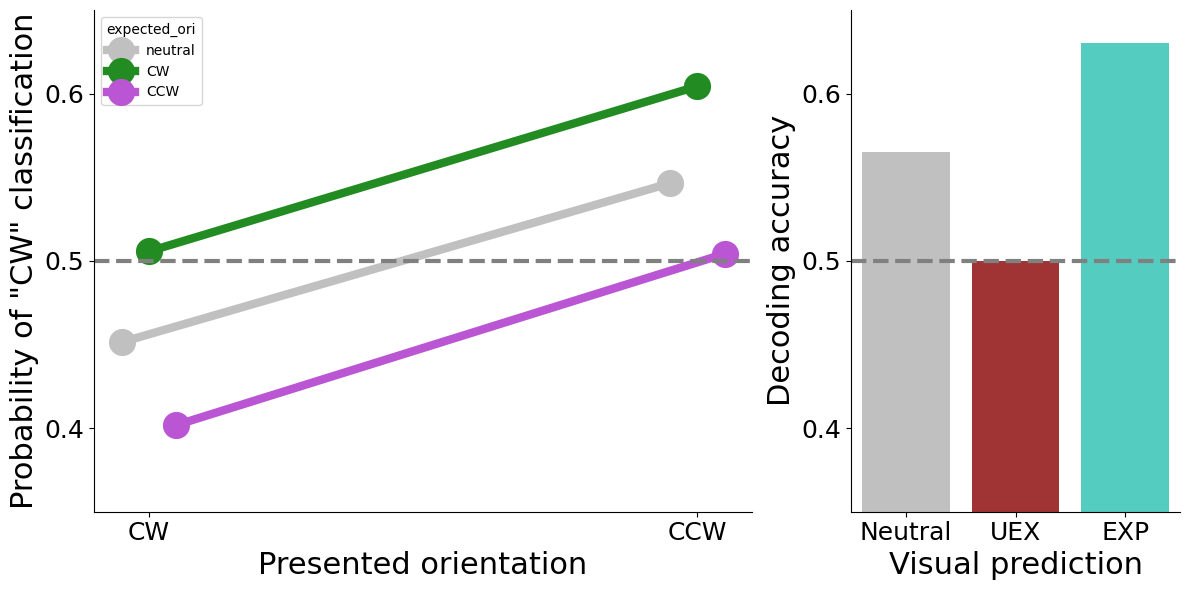

In [78]:
x = "presented_ori"  # Presented CW or
hue = "expected_ori"  # expected CW or CCW
y = "prob_cw"  # probability of choosing CW
savefig = True

fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=False,
    gridspec_kw={"width_ratios": [2, 1]}  # first subplot twice as wide
)

data = df[df["mechanism"] != "sharpening"].copy()
dat1 = data.groupby([hue, x])[y].mean().reset_index()

palette = ["silver", "forestgreen", "mediumorchid"]  # lighter grey
hue_order = ["neutral", "CW", "CCW"]

sns.pointplot(
    data=dat1,
    x="presented_ori",
    y="prob_cw",
    hue="expected_ori",
    hue_order=hue_order,
    dodge=0.1,
    join=True,
    errorbar=None,
    palette=palette,
    linewidth=6,
    ax=ax[0]
)

ax[0].axhline(0.5, color="grey", linestyle="--", lw=3)
ax[0].set_ylim(0.35, 0.65)
ax[0].set_xlim(-0.1, 1.1)
ax[0].set_ylabel('Probability of "CW" classification', fontsize=22)
ax[0].set_xlabel("Presented orientation", fontsize=22)
ax[0].set_yticks([0.4, 0.5, 0.6])
ax[0].set_yticklabels(["0.4", "0.5", "0.6"], fontsize=18)
ax[0].set_xticklabels(["CW", "CCW"], fontsize=18)

# Right subplot
x = "visual_prediction"
hue = "visual_prediction"
y = "correct"

data = df[df["mechanism"] != "sharpening"].copy()
dat2 = data.groupby([x])[y].mean().reset_index()

palette = ["silver", "firebrick", "turquoise"]
cat_type = pd.CategoricalDtype(categories=["neutral", "UEX", "EXP"], ordered=True)
dat2["visual_prediction"] = dat2["visual_prediction"].astype(cat_type)

sns.barplot(
    data=dat2,
    x="visual_prediction",
    y="correct",
    hue="visual_prediction",
    dodge=False,
    palette=palette,
    ax=ax[1]
)

ax[1].axhline(0.5, color="grey", linestyle="--", lw=3)
ax[1].set_ylim(0.35, 0.65)
ax[1].set_ylabel("Decoding accuracy", fontsize=22)
ax[1].set_xlabel("Visual prediction", fontsize=22)
ax[1].set_yticks([0.4, 0.5, 0.6])
ax[1].set_yticklabels(["0.4", "0.5", "0.6"], fontsize=18)
ax[1].set_xticklabels(["Neutral", "UEX", "EXP"], fontsize=18)

# Remove top and right spines
sns.despine()


plt.tight_layout()
if savefig:
    plt.savefig("figures/MVPA/bias_simulation.svg", dpi=300)
plt.show()
